In [1]:
from config import DATASET_DIR
from data import DataLoader
from features import ResNetFeatureExtractor
from summarizer import KMeansSummarizer, LSTMSummarizer, SupervisedSummarizer
from visualization import plot_keyframes, plot_feature_projection

/home/osama_ashraf/miniconda3/envs/dl-env/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/osama_ashraf/miniconda3/envs/dl-env/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
# Setup Data Loader and Feature Extractor
loader = DataLoader(DATASET_DIR)
features_extractor = ResNetFeatureExtractor()
video_id = 'AwmHb44_ouw'
video_path = f'{DATASET_DIR}/ydata-tvsum50-video/video/{video_id}.mp4'

--- ResNet + KMeans Approach ---


/home/osama_ashraf/miniconda3/envs/dl-env/lib/python3.10/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


Saved keyframes plot to results/AwmHb44_ouw_kmeans_keyframes.png


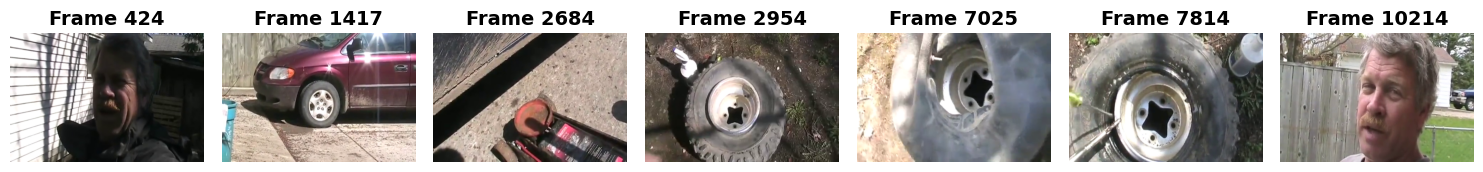

Saved PCA plot to results/AwmHb44_ouw_kmeans_pca.png


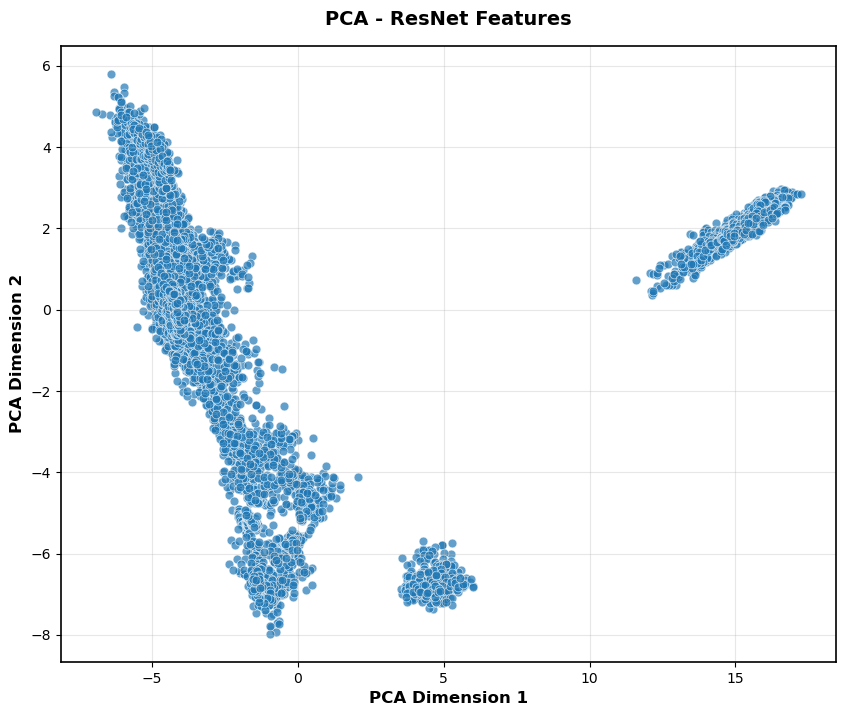

Saved TSNE plot to results/AwmHb44_ouw_kmeans_tsne.png


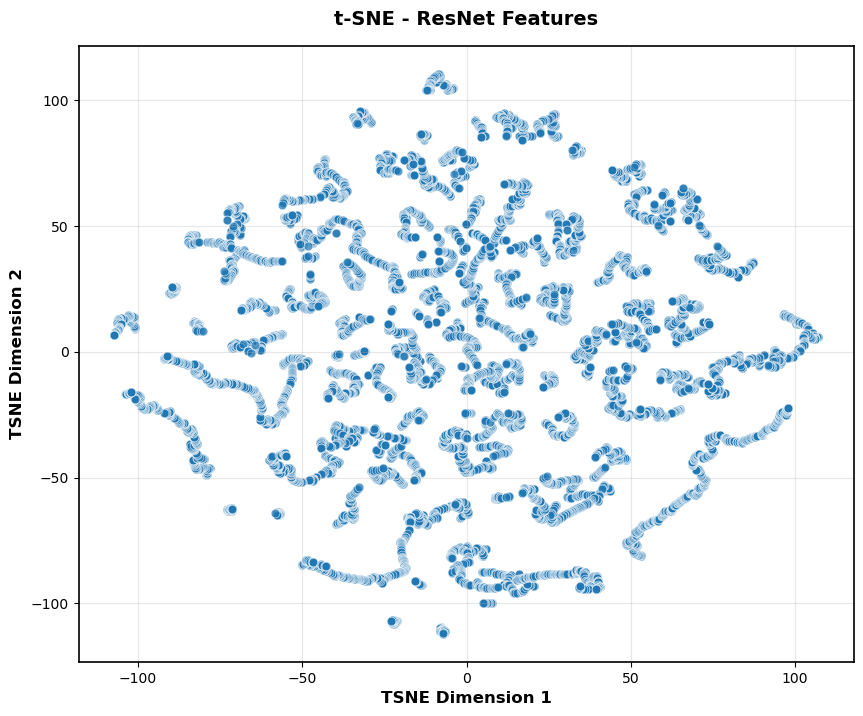

In [3]:
# 1. ResNet + KMeans Approach
print("--- ResNet + KMeans Approach ---")
kmeans_summ = KMeansSummarizer(loader, features_extractor)
key_indices_kmeans, kmeans_labels = kmeans_summ.summarize(video_id)

plot_keyframes(video_path, key_indices_kmeans, output_filename=f"{video_id}_kmeans_keyframes.png")
plot_feature_projection(kmeans_summ.all_features, labels=kmeans_labels, method='pca', title='PCA - ResNet Features', output_filename=f"{video_id}_kmeans_pca.png")
plot_feature_projection(kmeans_summ.all_features, labels=kmeans_labels, method='tsne', title='t-SNE - ResNet Features', output_filename=f"{video_id}_kmeans_tsne.png")

In [ ]:
# 2. LSTM Autoencoder + KMeans Approach
print("\n--- LSTM Autoencoder + KMeans Approach ---")
lstm_summ = LSTMSummarizer(loader, features_extractor)
key_indices_lstm, lstm_labels = lstm_summ.summarize(video_id)

plot_keyframes(video_path, key_indices_lstm, output_filename=f"{video_id}_lstm_keyframes.png")
plot_feature_projection(lstm_summ.lstm_features, labels=lstm_labels, method='pca', title='PCA - LSTM Features', output_filename=f"{video_id}_lstm_pca.png")
plot_feature_projection(lstm_summ.lstm_features, labels=lstm_labels, method='tsne', title='t-SNE - LSTM Features', output_filename=f"{video_id}_lstm_tsne.png")

In [ ]:
# 3. Supervised BiLSTM Predictor Approach
print("\n--- Supervised BiLSTM Predictor Approach ---")
supervised_summ = SupervisedSummarizer(loader, features_extractor)
supervised_summ.train_on_dataset(epochs=5)
key_indices_sup, sup_labels = supervised_summ.summarize(video_id)

plot_keyframes(video_path, key_indices_sup, output_filename=f"{video_id}_supervised_keyframes.png")
# Visualize the features space
if supervised_summ.all_features is not None:
    plot_feature_projection(supervised_summ.all_features, labels=sup_labels, method='pca', title='PCA - Features (Supervised Model)', output_filename=f"{video_id}_supervised_pca.png")
    plot_feature_projection(supervised_summ.all_features, labels=sup_labels, method='tsne', title='t-SNE - Features (Supervised Model)', output_filename=f"{video_id}_supervised_tsne.png")